## Uncertainty in Explanations via XAI Method Perturbation (Tabular)

In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns
import pickle

# Make numpy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing

In [34]:
from xplique.attributions import (IntegratedGradients, 
                                KernelShap, 
                                Lime, 
                                Occlusion,
                                SmoothGrad
                            )
from xplique.plots import plot_feature_impact, plot_mean_feature_impact, summary_plot_tabular

### Load dataset

In [4]:
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

raw_dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

In [5]:
dataset = raw_dataset.copy()
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [6]:
# the dataset contains na value, we just drop them
dataset = dataset.dropna()
# the origin column is not numeric so we convert it to a one hot-hot
dataset['Origin'] = dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
dataset = pd.get_dummies(dataset, columns=['Origin'], prefix='', prefix_sep='')
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,0,0,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,1,0,0
395,32.0,4,135.0,84.0,2295.0,11.6,82,0,0,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,0,0,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,0,0,1


In [7]:
# Splits
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset  = dataset.drop(train_dataset.index)

In [8]:
# Separate features from labels
train_features = train_dataset.copy()
test_features  = test_dataset.copy()

train_labels = train_features.pop('MPG')
test_labels  = test_features.pop('MPG')

In [9]:
# Normalize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features.values)
test_features  = scaler.transform(test_features.values)

In [10]:
inputs_tf, targets_tf = tf.cast(test_features, tf.float32), tf.cast(test_labels, tf.float32)
targets_tf = tf.expand_dims(targets_tf, axis=-1)
new_targets_tf = tf.ones((78,1))
len(targets_tf)

78

In [11]:
features_name = [
    'Cylinders',
    'Displacement',
    'Horsepower',
    'Weight',
    'Acceleration',
    'Model Year',
    'Europe',
    'Japan',
    'USA'
]

### Load/Train Model

In [12]:
# Whether to train a model or load a pretrained one
train_model = False
model_path = './models/ann_tabular.h5'

In [13]:
if train_model:
    # Define a simple ANN
    model = keras.Sequential([
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(loss='mean_absolute_error', optimizer=tf.keras.optimizers.Adam(0.001))

    %%time
    history = model.fit(train_features, train_labels, validation_split=0.2, verbose=0, epochs=100)
    model.save(model_path)
else:
    model = tf.keras.models.load_model(model_path)

In [ ]:
explainer = IntegratedGradients(model)
explanation = explainer(inputs_tf, new_targets_tf)

### Compute variance analytically

In [16]:
# Explain one sample
ex_ind = 0
ex_row, ex_target = np.expand_dims(inputs_tf[ex_ind], axis=0), np.expand_dims([1], axis=0)

ex_exp = explainer(ex_row, ex_target)
ex_exp

<tf.Tensor: shape=(1, 9), dtype=float32, numpy=
array([[ 1.184, -3.225, -2.965, -1.665,  5.708, -0.866,  1.108,  1.572,
         4.913]], dtype=float32)>

In [17]:
# Compute derivative of explanation w.r.t XAI parameter via FDM
# Here as an example: steps in IntegGrad (default 50), so only one parameter
dtheta = 1
n, m = 1, ex_exp.shape[1]
derivative_e_theta = np.zeros((m, n))
default_steps = 50

# For every parameter perturbation, we get a new column in the Jacobian
for i in range(n):

    # Compute perturbed explanation
    perturbed_explainer = IntegratedGradients(model, steps = default_steps + dtheta)
    perturbed_exp = perturbed_explainer(ex_row, ex_target)

    # Compute FDM (central differences)
    derivative_e_theta[:, i] = (perturbed_exp - ex_exp) / dtheta

In [18]:
perturbed_exp

<tf.Tensor: shape=(1, 9), dtype=float32, numpy=
array([[ 1.192, -3.212, -2.97 , -1.667,  5.698, -0.891,  1.111,  1.576,
         4.938]], dtype=float32)>

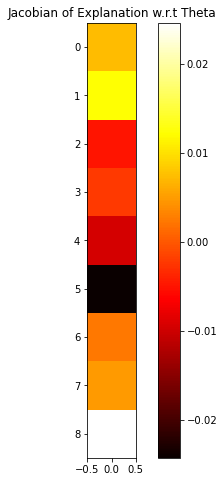

In [19]:
plt.figure(figsize=(8,8))
plt.imshow(derivative_e_theta, cmap='hot')
plt.title("Jacobian of Explanation w.r.t Theta")
plt.colorbar()
plt.show()

In [20]:
# Approximate covariance of explanation
perturbation_std = 5
sigma_squared = perturbation_std ** 2
variance_explanation = sigma_squared * derivative_e_theta @ derivative_e_theta.T

# Total variance is the trace of the cov. matrix
print("Total Variance of Explanation (Analytical):", np.trace(variance_explanation))

Total Variance of Explanation (Analytical): 0.03854027389671444


In [21]:
# Normalized total variance is the trace of the cov. matrix divided by the L2-norm of the unperturbed explanation
print("Normalized Variance of Explanation:", np.trace(variance_explanation) / (m * np.linalg.norm(explanation)))

Normalized Variance of Explanation: 5.251297098604256e-05


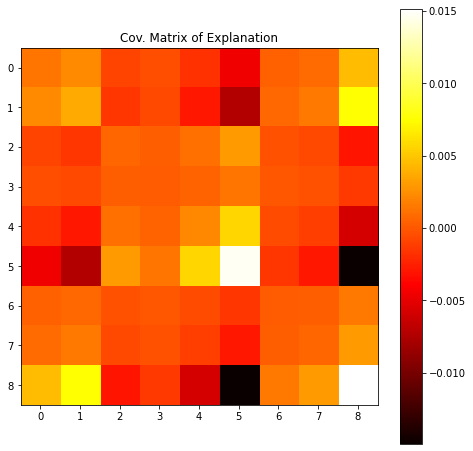

In [22]:
plt.figure(figsize=(8,8))
plt.imshow(variance_explanation, cmap='hot')
plt.title("Cov. Matrix of Explanation")
plt.colorbar()
plt.show()

### Compute variance empirically

In [18]:
num_perturbations = 10
perturbation_std = 5  # same as above for analytical formula
sigma_squared = perturbation_std ** 2

perturbed_explanations = []
for _ in range(num_perturbations):
    # Add Gaussian noise to the XAI parameter
    perturbed_steps = int(np.round(default_steps + np.random.normal(0, perturbation_std, n)))

    # Generate explanation for perturbed parameter
    perturbed_explainer = IntegratedGradients(model, steps = perturbed_steps)
    perturbed_explanations.append( perturbed_explainer(ex_row, ex_target) )

# Stack explanations and compute covariance matrix
explanation_matrix = np.stack(perturbed_explanations, axis=0).squeeze()
empirical_covariance = np.cov(explanation_matrix, rowvar=False)

# Compute total variance (trace of the covariance matrix)
empirical_total_variance = np.trace(empirical_covariance)

print("Empirical Total Variance of Explanation:", empirical_total_variance)

Empirical Total Variance of Explanation: 0.0010396797153226266


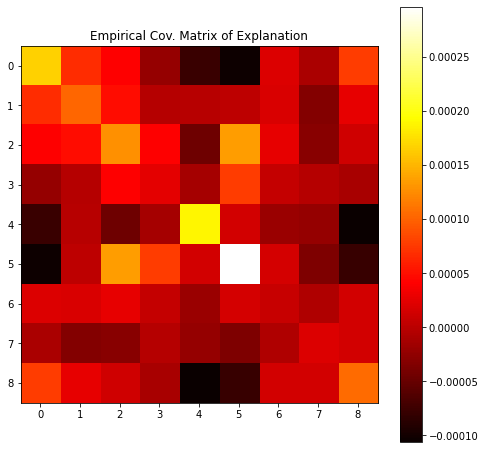

In [19]:
plt.figure(figsize=(8,8))
plt.imshow(empirical_covariance, cmap='hot')
plt.title("Empirical Cov. Matrix of Explanation")
plt.colorbar()
plt.show()

### Analytical vs Empirical (multiple methods, multiple variances)

In [ ]:
xai_methods  = {'Lime': lambda model, kernel_width: Lime(model, kernel_width = kernel_width), # stochastic
                'SmoothGrad': lambda model, noise_std: SmoothGrad(model, noise = noise_std),  # stochastic
                'IntegratedGradients': lambda model, steps: IntegratedGradients(model, steps = steps), # deterministic
                'Occlusion': lambda model, ov: Occlusion(model, occlusion_value = ov), # deterministic
                }

How does the 'mean MUE per sigma_squared' behave for different default/starting XAI parameters?

In [ ]:
stds = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1] # for floats
#stds = [2, 3, 4, 5] # for ints

num_perturbations = 10 # for empirical cov.
#dtheta = 1e-3 # differential for ana. cov.
m = len(features_name)
n = 1 # just one XAI param.

#default_kws = [1, 2, 3, 4, 5] # lime
default_smooth_noises = [0.1, 0.2, 0.3, 0.4, 0.5] # smooth grad.
#default_steps = [20, 30, 40, 50, 60, 70, 80] # integ. grads
#default_ovs = [-2, -1, 0, 1, 2] # occlusion

In [37]:
ex_inds = np.arange(10)
results = {}

#for default_kw in default_kws:
#for default_step in default_steps: 
#for default_ov in default_ovs:
for default_noise in default_smooth_noises:
    
    #print(f'kw = {default_kw}')
    #explainer = Lime(model, kernel_width = default_kw)
    #print(f'steps = {default_step}')
    #explainer = IntegratedGradients(model, steps = default_step)
    #print(f'ov = {default_ov}')
    #explainer = Occlusion(model, occlusion_value = default_ov)
    print(f'smooth noise = {default_noise}')
    explainer = SmoothGrad(model, noise = default_noise)
    
    mue_per_s2 = 0.0
    for ex_ind in ex_inds:
        # Sample to explain
        ex_row, ex_target = np.expand_dims(inputs_tf[ex_ind], axis=0), np.expand_dims([1], axis=0)
        
        explanation = explainer(ex_row, ex_target) # sample explanation
        # Norm of explanation (for normalization of total variance)
        norm_exp_squared = np.linalg.norm(explanation)**2
        
        for std in stds:
        
            perturbed_explanations = []
            for _ in range(num_perturbations):
                # Add Gaussian noise to the XAI parameter
                #perturbed_kw = default_kw + np.random.normal(0, std, n)
                #perturbed_step = max( int(np.round(default_step + np.random.normal(0, std, n))), 1 )
                #perturbed_ov = default_ov + np.random.normal(0, std, n)
                perturbed_noise = default_noise + np.random.normal(0, std, n)

                # Generate explanation for perturbed parameter
                #perturbed_explainer = Lime(model, kernel_width = perturbed_kw)
                #perturbed_explainer = IntegratedGradients(model, steps = perturbed_step)
                #perturbed_explainer = Occlusion(model, occlusion_value = perturbed_ov[0].astype(np.float32))
                perturbed_explainer = SmoothGrad(model, noise = perturbed_noise[0].astype(np.float32))
                
                perturbed_explanations.append( perturbed_explainer(ex_row, ex_target) )
        
            # Stack explanations and compute covariance matrix
            explanation_matrix = np.stack(perturbed_explanations, axis=0).squeeze()
            empirical_covariance = np.cov(explanation_matrix, rowvar=False)

            # Compute total variance (trace of the covariance matrix)
            mue_per_s2 += np.trace(empirical_covariance) / norm_exp_squared / m / (std**2) # per sigma squared
            
    mue_per_s2 /= (len(stds) * len(ex_inds)) # aggregated over samples and stds
    
    #results[default_kw] = mue_per_s2
    #results[default_step] = mue_per_s2
    #results[default_ov] = mue_per_s2
    results[default_noise] = mue_per_s2

smooth noise = 0.1
smooth noise = 0.2
smooth noise = 0.3
smooth noise = 0.4
smooth noise = 0.5


Text(0, 0.5, 'MUE/sig_squared')

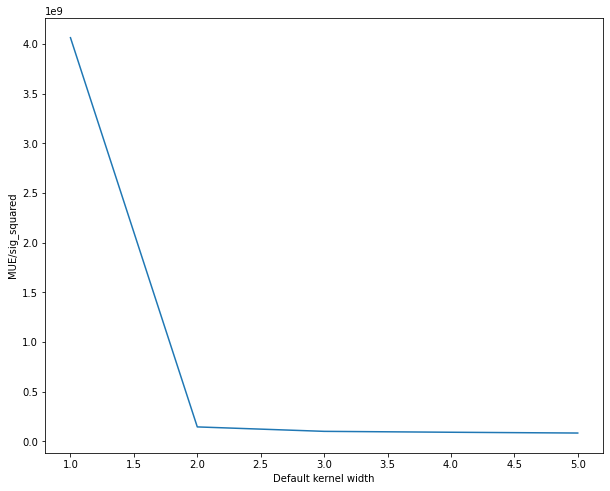

In [ ]:
# LIME, kernel width
plt.figure(figsize=(10,8))
plt.plot(default_kws, results.values())
plt.xlabel('Default kernel width')
plt.ylabel('MUE/sig_squared')

Text(0, 0.5, 'MUE/sig_squared')

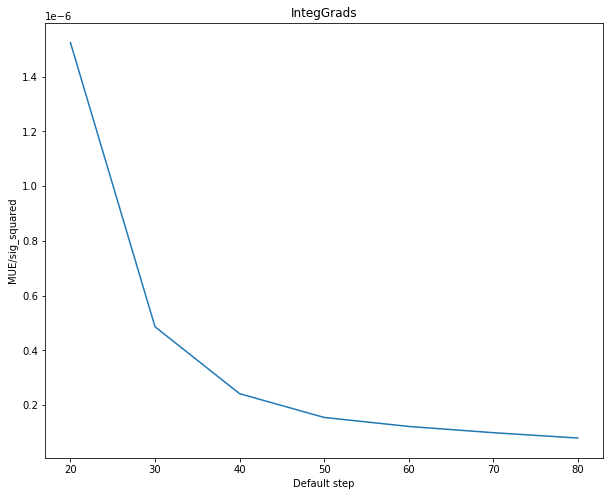

In [22]:
# IG, steps
plt.figure(figsize=(10,8))
plt.plot(default_steps, results.values())
plt.title('IntegGrads')
plt.xlabel('Default step')
plt.ylabel('MUE/sig_squared')

Text(0, 0.5, 'MUE/sig_squared')

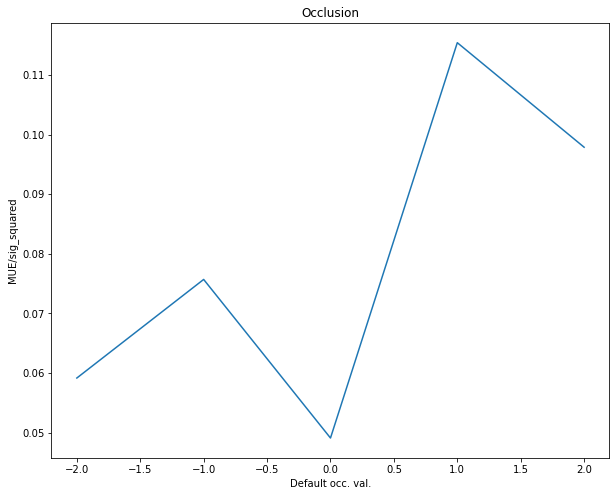

In [33]:
# Occlusion, OV
plt.figure(figsize=(10,8))
plt.plot(default_ovs, results.values())
plt.title('Occlusion')
plt.xlabel('Default occ. val.')
plt.ylabel('MUE/sig_squared')

Text(0, 0.5, 'MUE/sig_squared')

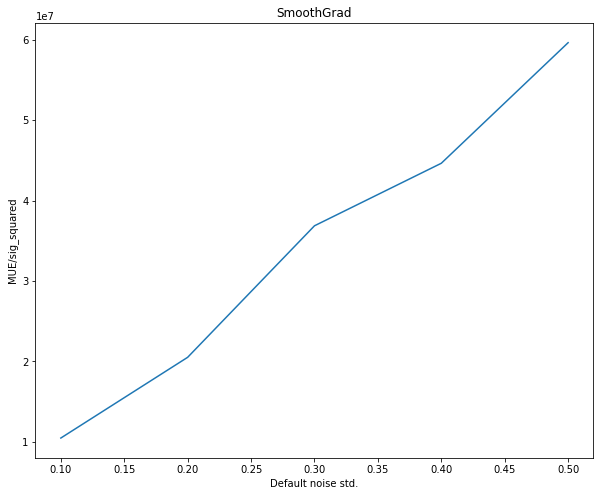

In [38]:
# SmoothGrad, Noise std. dev.
plt.figure(figsize=(10,8))
plt.plot(default_smooth_noises, results.values())
plt.title('SmoothGrad')
plt.xlabel('Default noise std.')
plt.ylabel('MUE/sig_squared')

In [ ]:
ex_inds = np.arange(10)
results, jacobi_mats, empirical_exps, unperturbed_exps = {}, {}, {}, {}

for ex_ind in ex_inds:
    # Sample to explain
    ex_row, ex_target = np.expand_dims(inputs_tf[ex_ind], axis=0), np.expand_dims([1], axis=0)
    
    # Store results for plotting
    results[ex_ind]  = {name: {'analytical': [], 'empirical': []} for name in xai_methods.keys()}
    jacobi_mats[ex_ind] = {}
    empirical_exps[ex_ind] = {}
    unperturbed_exps[ex_ind] = {}

    print('\n*********')
    print('Sample ' + str(ex_ind))
    for name, constructor in xai_methods.items():
        print('\n' + name)
        empirical_exps[ex_ind][name] = {}
        
        # Get explanation for unperturbed input
        #explainer = constructor(model, steps = default_steps) # instantiate explainer with default params
        #explainer = constructor(model, nb_samples = default_shap)
        explainer = constructor(model, kernel_width = default_kw)
        explanation = explainer(ex_row, ex_target) # sample explanation
        unperturbed_exps[ex_ind][name] = explanation

        # Norm of explanation (for normalization of total variance)
        norm_exp_squared = np.linalg.norm(explanation)**2
    
        # Precompute Jacobian (stays fixed for every std)
        derivative_e_theta = np.zeros((m, n))
        # For every feature perturbation, we get a new column in the Jacobian
        for i in range(n):
            # Compute explanations for perturbed explainer
            #perturbed_explainer = constructor(model, steps = default_steps + dtheta)
            #perturbed_explainer = constructor(model, nb_samples = default_shap + dtheta)
            perturbed_explainer = constructor(model, kernel_width = default_kw + dtheta)
            perturbed_exp = perturbed_explainer(ex_row, ex_target)
        
            # Compute FDM (central differences)
            derivative_e_theta[:, i] = (perturbed_exp - explanation) / dtheta
        jacobi_mats[ex_ind][name] = derivative_e_theta
        
        jjt = derivative_e_theta @ derivative_e_theta.T # Compute jacobian product only once
        for std in stds:
            ### Analytical
            sigma_squared = std ** 2
            covariance_ana = sigma_squared * jjt
            
            # Total variance is the trace of the cov. matrix
            total_var = np.trace(covariance_ana)/norm_exp_squared
            print("Analytical Variance (std = ", std, "):", total_var)
            results[ex_ind][name]['analytical'].append(total_var)
            
            ### Empirical
            perturbed_explanations = []
            for _ in range(num_perturbations):
                # Add Gaussian noise to the XAI parameter
                #perturbed_theta = int(np.round(default_steps + np.random.normal(0, std, n)))
                #perturbed_theta = int(np.round(default_shap + np.random.normal(0, std, n)))
                perturbed_theta = default_kw + np.random.normal(0, std, n)
            
                # Generate explanation for perturbed explainer
                #perturbed_explainer = constructor(model, steps = perturbed_theta)
                #perturbed_explainer = constructor(model, nb_samples = perturbed_theta)
                perturbed_explainer = constructor(model, kernel_width = perturbed_theta)
                perturbed_explanations.append( perturbed_explainer(ex_row, ex_target) )
            
            # Stack explanations and compute covariance matrix
            explanation_matrix = np.stack(perturbed_explanations, axis=0)
            covariance_emp = np.cov(explanation_matrix.squeeze(), rowvar=False)

            total_var = np.trace(covariance_emp)/norm_exp_squared
            print("Empirical Variance (std = ", std, "):", total_var)
            results[ex_ind][name]['empirical'].append(total_var)
            
            # Store explanations for normality checks
            empirical_exps[ex_ind][name][std] = np.stack(perturbed_explanations, axis=0)

In [68]:
# Store expriment dictionaries
experiments = {'results': results, 
               'jacobi_mats': jacobi_mats,
               'empirical_exps': empirical_exps, 
               'unperturbed_exps': unperturbed_exps}

#with open('./experiments/experiments_input_tabular_10ex_10pert.pickle', 'wb') as handle:
#    pickle.dump(experiments, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# Load experiments
#exp_path = './experiments/experiments_input_tabular_10ex_10pert.pickle' # MUE results
#exp_path = './experiments/experiments_input_tabular_3ex_1000pert.pickle' # distribution plots
#with open(exp_path, 'rb') as handle:
#    experiments = pickle.load(handle)

In [69]:
# Aggregate results
agg_results = {name: {'analytical': [], 'empirical': []} for name in xai_methods.keys()}
stds = np.asarray(stds)
for name in xai_methods.keys():
    agg_sum = np.zeros(len(stds))
    for ex_ind in ex_inds:
        agg_sum += experiments['results'][ex_ind][name]['analytical']
    agg_results[name]['analytical'] = agg_sum/len(ex_inds)

    agg_sum = np.zeros(len(stds))
    for ex_ind in ex_inds:
        agg_sum += experiments['results'][ex_ind][name]['empirical']
    agg_results[name]['empirical'] = agg_sum/len(ex_inds)
#agg_results

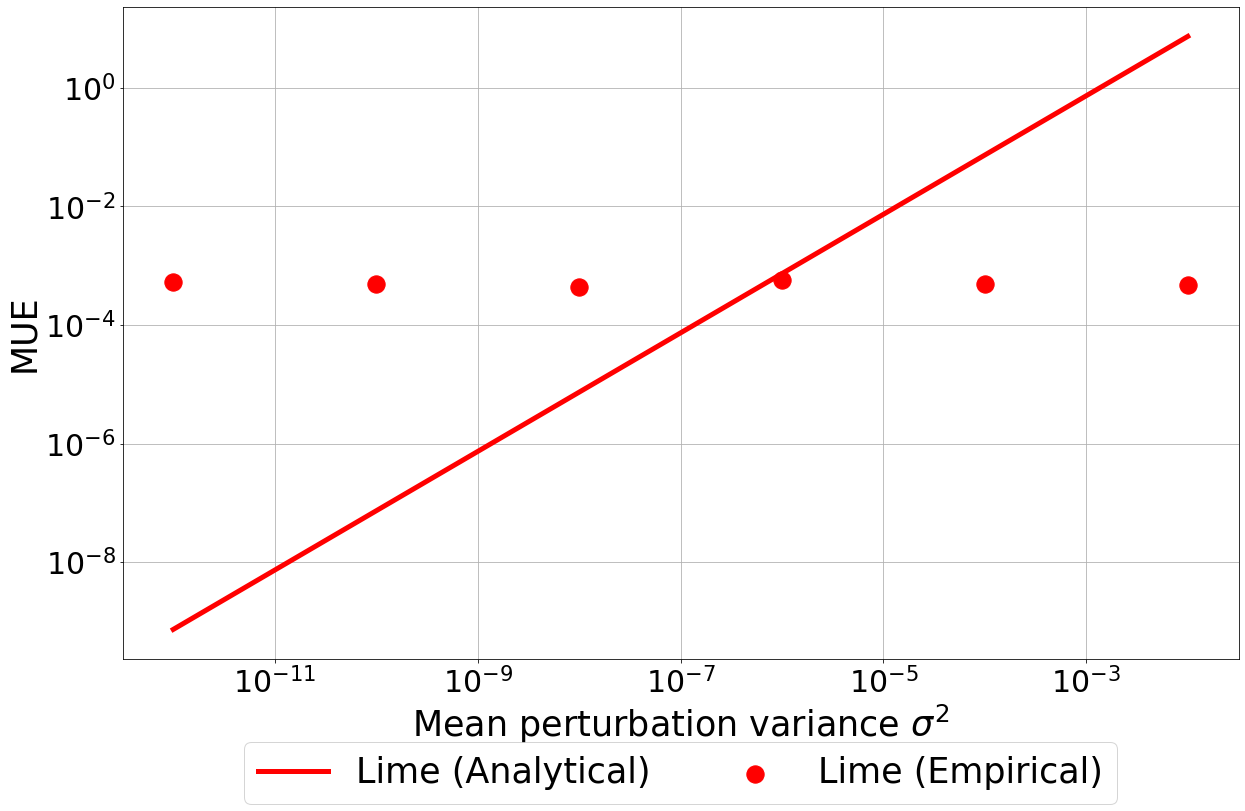

In [ ]:
# Plot aggregations
# Lime kernel = 45
colors=['red', 'blue', 'orange', 'green', 'black', 'brown', 'olive']
stds = np.asarray(stds)
fsize=35
fig = plt.figure(figsize=(20, 12))
for (name, data), col in zip(agg_results.items(), colors):
    plt.plot(stds*stds, np.asarray(data['analytical'])[:len(stds)]/m, label=f"{name} (Analytical)", c=col, lw=5)
    plt.scatter(stds*stds, np.asarray(data['empirical'])[:len(stds)]/m,  marker='o', 
                label=f"{name} (Empirical)", c=col, s=300)
plt.xlabel('Mean perturbation variance $\sigma^2$', fontsize=fsize)
plt.ylabel('MUE', fontsize=fsize)
plt.xscale('log'); plt.yscale('log')
plt.xticks(fontsize=fsize-5);plt.yticks(fontsize=fsize-5)
plt.legend(fontsize=fsize, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.grid(True)
plt.show()
#fig.savefig('./figures/uncertainties_input_tabular_agg.png', bbox_inches='tight')

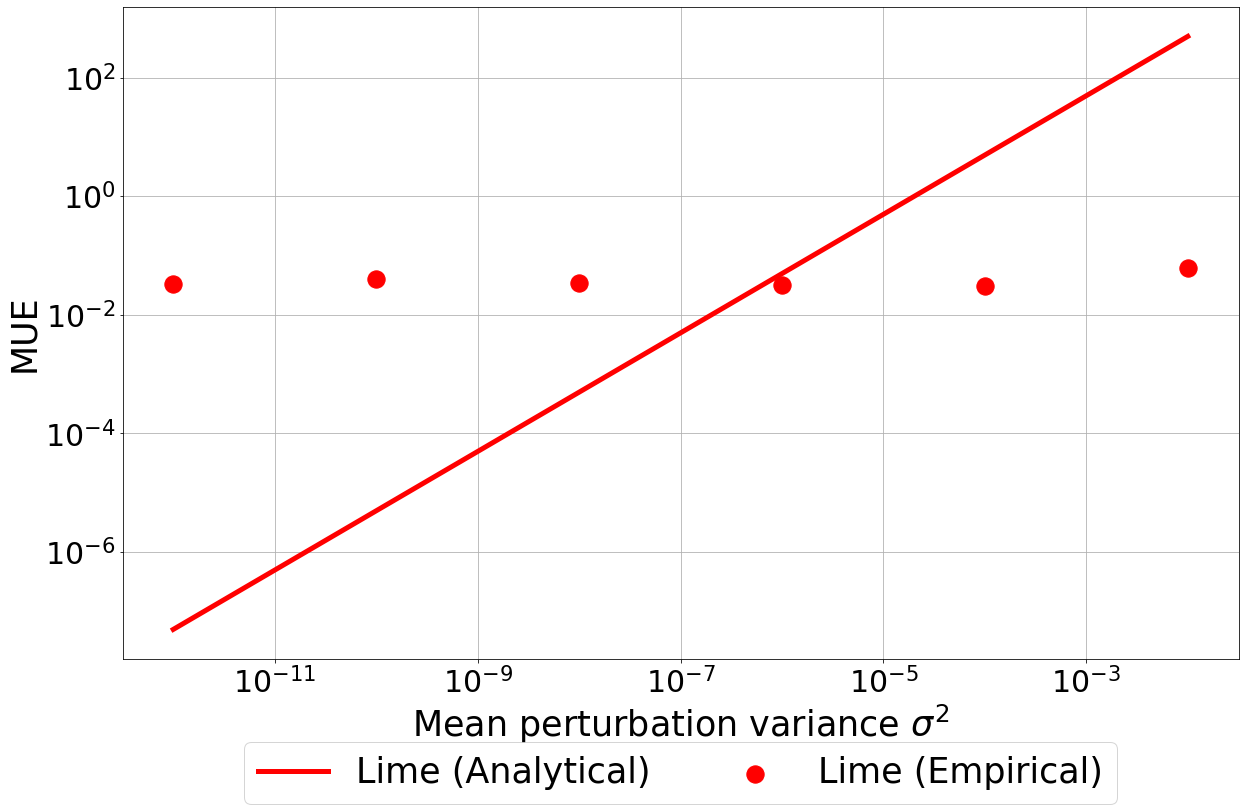

In [ ]:
# Plot aggregations
# Lime kernel = 1
colors=['red', 'blue', 'orange', 'green', 'black', 'brown', 'olive']
stds = np.asarray(stds)
fsize=35
fig = plt.figure(figsize=(20, 12))
for (name, data), col in zip(agg_results.items(), colors):
    plt.plot(stds*stds, np.asarray(data['analytical'])[:len(stds)]/m, label=f"{name} (Analytical)", c=col, lw=5)
    plt.scatter(stds*stds, np.asarray(data['empirical'])[:len(stds)]/m,  marker='o', 
                label=f"{name} (Empirical)", c=col, s=300)
plt.xlabel('Mean perturbation variance $\sigma^2$', fontsize=fsize)
plt.ylabel('MUE', fontsize=fsize)
plt.xscale('log'); plt.yscale('log')
plt.xticks(fontsize=fsize-5);plt.yticks(fontsize=fsize-5)
plt.legend(fontsize=fsize, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.grid(True)
plt.show()
#fig.savefig('./figures/uncertainties_input_tabular_agg.png', bbox_inches='tight')

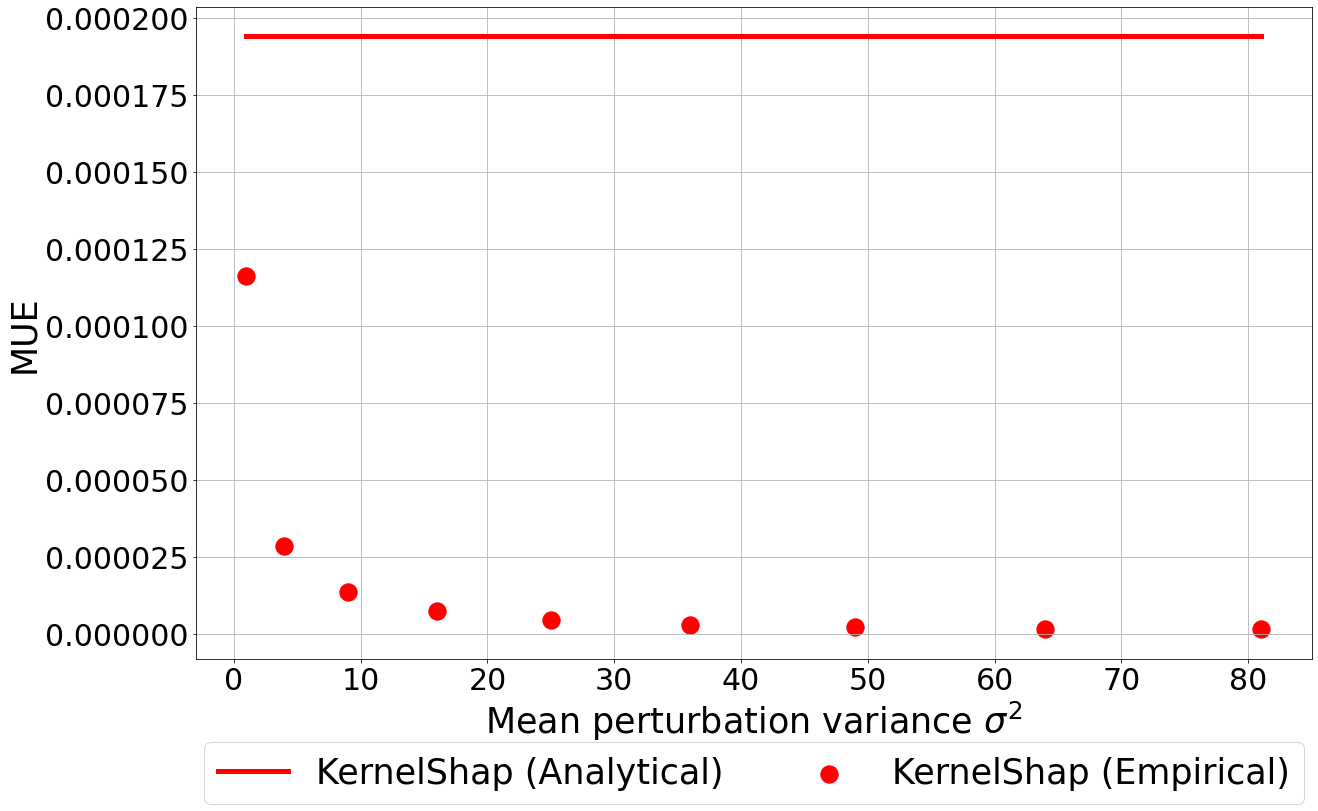

In [38]:
# Plot aggregations
colors=['red', 'blue', 'orange', 'green', 'black', 'brown', 'olive']
stds = np.asarray(stds)
fsize=35
fig = plt.figure(figsize=(20, 12))
for (name, data), col in zip(agg_results.items(), colors):
    plt.plot(stds*stds, np.asarray(data['analytical'])[:len(stds)]/m/(stds**2), label=f"{name} (Analytical)", c=col, lw=5)
    plt.scatter(stds*stds, np.asarray(data['empirical'])[:len(stds)]/m/(stds**2),  marker='o', 
                label=f"{name} (Empirical)", c=col, s=300)
plt.xlabel('Mean perturbation variance $\sigma^2$', fontsize=fsize)
plt.ylabel('MUE', fontsize=fsize)
#plt.xscale('log')
#plt.yscale('log')
plt.xticks(fontsize=fsize-5);plt.yticks(fontsize=fsize-5)
plt.legend(fontsize=fsize, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.grid(True)
plt.show()
#fig.savefig('./figures/uncertainties_input_tabular_agg.png', bbox_inches='tight')

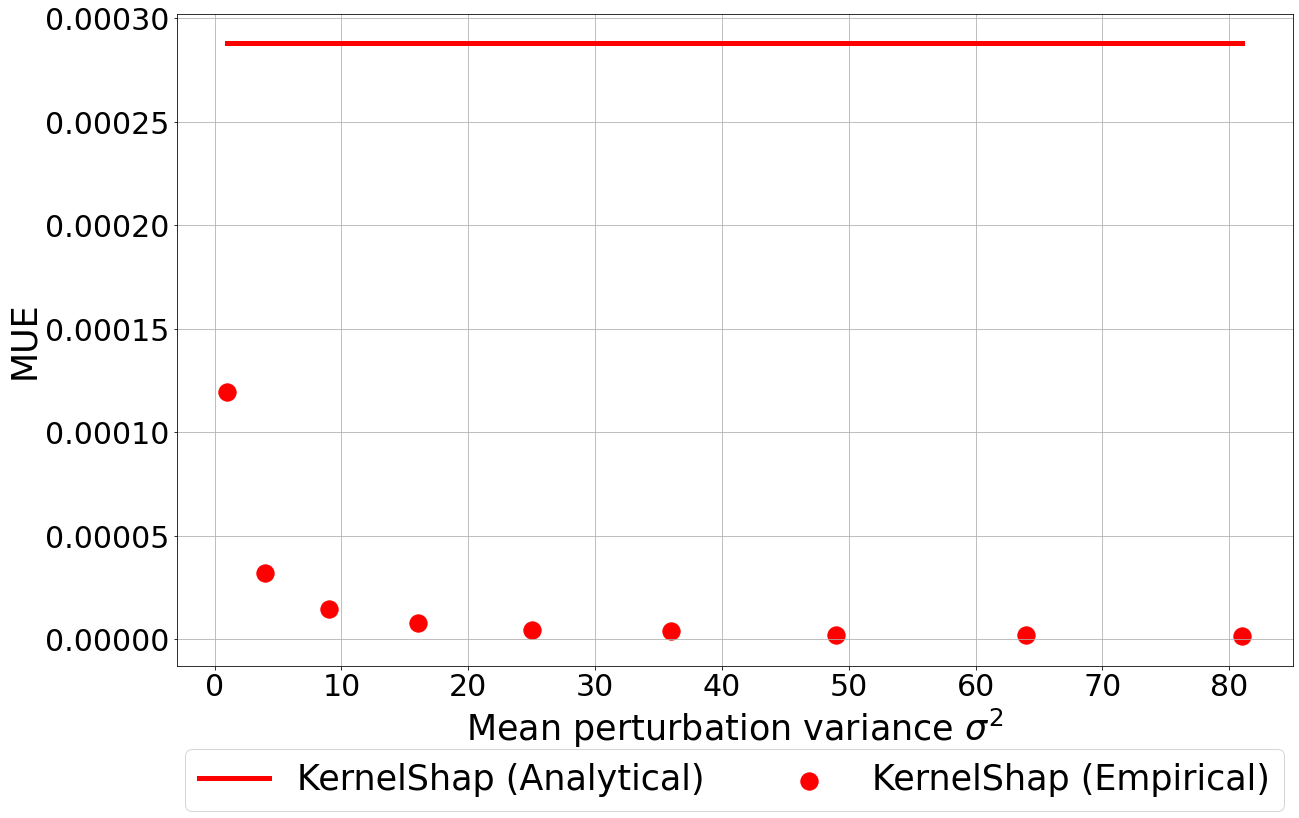

In [43]:
# Plot aggregations
colors=['red', 'blue', 'orange', 'green', 'black', 'brown', 'olive']
stds = np.asarray(stds)
fsize=35
fig = plt.figure(figsize=(20, 12))
for (name, data), col in zip(agg_results.items(), colors):
    plt.plot(stds*stds, np.asarray(data['analytical'])[:len(stds)]/m/(stds**2), label=f"{name} (Analytical)", c=col, lw=5)
    plt.scatter(stds*stds, np.asarray(data['empirical'])[:len(stds)]/m/(stds**2),  marker='o', 
                label=f"{name} (Empirical)", c=col, s=300)
plt.xlabel('Mean perturbation variance $\sigma^2$', fontsize=fsize)
plt.ylabel('MUE', fontsize=fsize)
#plt.xscale('log')
#plt.yscale('log')
plt.xticks(fontsize=fsize-5);plt.yticks(fontsize=fsize-5)
plt.legend(fontsize=fsize, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.grid(True)
plt.show()
#fig.savefig('./figures/uncertainties_input_tabular_agg.png', bbox_inches='tight')

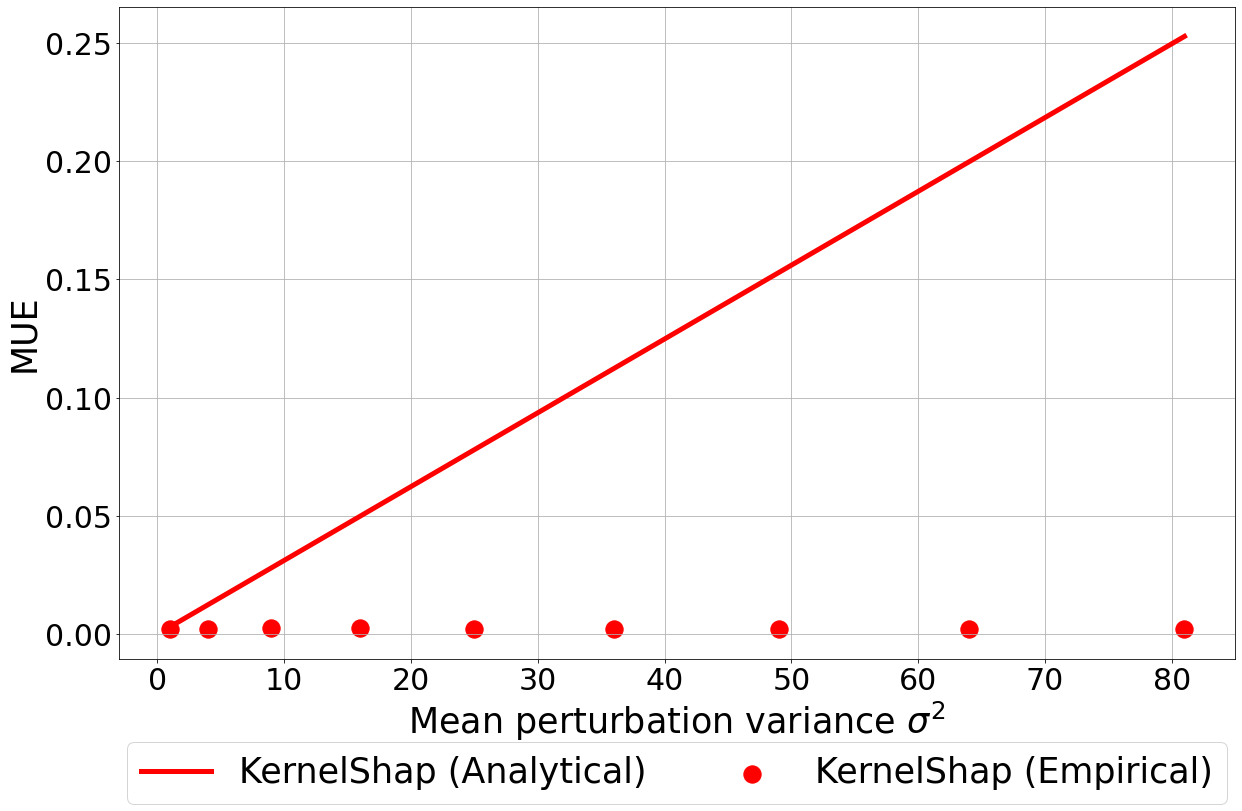

In [49]:
# Plot aggregations
colors=['red', 'blue', 'orange', 'green', 'black', 'brown', 'olive']
stds = np.asarray(stds)
fsize=35
fig = plt.figure(figsize=(20, 12))
for (name, data), col in zip(agg_results.items(), colors):
    plt.plot(stds*stds, np.asarray(data['analytical'])[:len(stds)]/m, label=f"{name} (Analytical)", c=col, lw=5)
    plt.scatter(stds*stds, np.asarray(data['empirical'])[:len(stds)]/m,  marker='o', 
                label=f"{name} (Empirical)", c=col, s=300)
plt.xlabel('Mean perturbation variance $\sigma^2$', fontsize=fsize)
plt.ylabel('MUE', fontsize=fsize)
#plt.xscale('log')
#plt.yscale('log')
plt.xticks(fontsize=fsize-5);plt.yticks(fontsize=fsize-5)
plt.legend(fontsize=fsize, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.grid(True)
plt.show()
#fig.savefig('./figures/uncertainties_input_tabular_agg.png', bbox_inches='tight')